# Prequisite (cukup jalankan sekali)


In [1]:
import nltk

# nltk.download('stopwords')
# nltk.download('words')
# nltk.download('wordnet')
# nltk.download('averaged_perceptron_tagger')
# nltk.download('averaged_perceptron_tagger_eng')

# Import

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import emoji
from wordcloud import WordCloud
import nltk

from collections import Counter
import math

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

import re
from nltk.corpus import stopwords
from nltk.corpus import words as nltk_words
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet


c:\Users\isalo\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


# Data Preview

In [2]:
df = pd.read_parquet('train.parquet')
df.head()

,text,label
0,hey I am looking for Xray baggage datasets can...,not_spam
1,"""Get rich quick! Make millions in just days wi...",spam
2,URGENT MESSAGE: YOU WON'T BELIEVE WHAT WE HAVE...,spam
3,[Google AI Blog: Contributing Data to Deepfake...,not_spam
4,Trying to see if anyone already has timestamps...,not_spam


In [4]:
df.shape

(8175, 2)

In [5]:
df.isnull().sum()

text     0
label    0
dtype: int64

In [6]:
print("Rata-rata panjang kata:", round(df['text'].apply(len).mean()))
print("Panjang maksimum kata:", df['text'].apply(len).max())
print("Panjang minimum kata:", df['text'].apply(len).min())


Rata-rata panjang kata: 369
Panjang maksimum kata: 41544
Panjang minimum kata: 2


In [7]:
df['label'].value_counts()

label
spam        4125
not_spam    4050
Name: count, dtype: int64

# EDA

### Distribusi noise

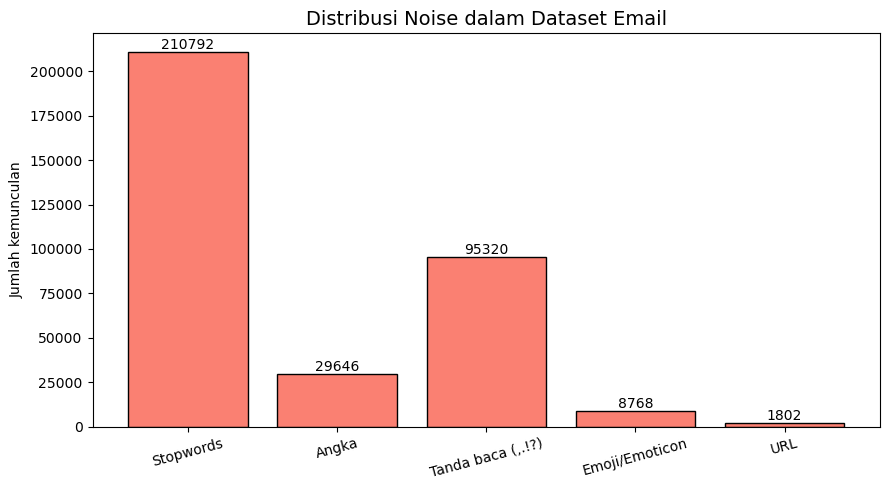

In [8]:
# Extract all words from dataset
all_words = ' '.join(df['text'].tolist())
stopword_en = set(stopwords.words('english'))

# Dictionary of noise count
noise = {
    'Stopwords': sum(all_words.lower().split().count(w) for w in stopword_en),
    'Angka': len(re.findall(r'\d', all_words)),
    'Tanda baca (,.!?)': len(re.findall(r'[,\.!?;:\"\']', all_words)),
    'Emoji/Emoticon': len(re.findall(r'[:;=]-?[\)\(\|DPp]|[\U0001F300-\U0001FFFF]', all_words)),
    'URL': len(re.findall(r'http\S+|www\S+', all_words)),
}

# Plot styling
plt.figure(figsize=(9, 5))
bars = plt.bar(noise.keys(), noise.values(), color='salmon', edgecolor='black')
plt.bar_label(bars)
plt.title('Distribusi Noise dalam Dataset Email', fontsize=14)
plt.ylabel('Jumlah kemunculan')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


### Macam Emoji

In [10]:
print(re.findall(r'[:;=]-?[\)\(\|DPp]|[\U0001F300-\U0001FFFF]', all_words))

['👋', '👋', '👋', '😴', '😒', '🌶', '🌶', '🌶', '💪', '🏃', '🥦', '💪', '💪', '💪', '🙌', '🙌', '🙌', '🤩', '🤩', '🤩', '👋', '💥', '🤳', '🤳', '💻', '🔥', '🚫', '🔥', '🔥', '🤑', '💰', '💰', ':)', '👀', '📣', '📈', '🚀', '🤑', '👉', '💕', '💬', '🔧', '🛠', '👍', '📝', '👥', '🤩', '🌸', '🌸', '🌸', '🤩', '🤩', '🤩', '😝', '😝', '😝', '🤯', '🤯', '🤯', ';D', '😩', ':)', ':-|', ':-|', ':-|', '🎉', '🎉', '🎉', ';)', '🚨', '🚨', '🦐', '🦐', '🍔', '🍔', '🍟', '🍟', '💥', '💥', '🎁', '🤯', '🔥', '💥', '👨', '🎤', '👩', '🎤', '🔞', '🦄', '🤑', '🤑', '🤑', '🏃', '🏃', '🏃', '🥑', '🎉', '🥳', '💥', '🤑', '💪', '👟', '🌴', '🌞', '👀', '💬', '🤑', '💰', '🔥', '🔥', '🔥', '🔥', '🔥', '🔥', '🔥', '🔥', '👉', '🏼', '🤯', '🤯', '🚫', '👉', '🤑', '🎉', '👍', '🙌', '🚨', '🚨', '🚨', '🚨', '🚨', '🚨', '🔥', '🔥', '🔥', '🔥', '🔥', '🔥', '🎉', '🎉', '🎉', '🎉', '🎉', '🎉', '🤑', '🤑', '🤑', '🤑', '🤑', '🚨', '🚨', '🏋', '🏋', '💪', '💪', '📚', '🤑', '💰', '🤑', '💰', '🤑', '📣', '📣', '📣', '😎', '🚨', '🚨', '🎉', '🎉', '🎉', '🤡', '🐱', '😜', '😂', '👌', '🔥', '🔥', '🔥', '🤑', '🤑', '🤑', '🎉', '🎉', '🎉', '🥧', '🥧', '🥧', '💰', '💰', '💰', '=p', '=p', '=p', '👉', '👉', '👉', '🤑', '

### Preview bentuk asli noise

In [11]:
# Tokenisasi per kata
tokens = all_words.lower().split()

# Dictionary of noise frequency count
noise_freq = {
    'Stopwords': Counter(w for w in tokens if w in stopword_en),
    'Angka': Counter(re.findall(r'\b\d+\b', spam_text)),
    'Tanda baca (,.!?)': Counter(re.findall(r'[,\.!?;:\"\']', spam_text)),
    'Emoji/Emoticon': Counter(re.findall(r'[:;=]-?[\)\(\|DPp]|[\U0001F300-\U0001FFFF]', spam_text)),
    'URL': Counter(re.findall(r'http\S+|www\S+', spam_text)),
}

# Dictionary of colormap for each noise category
cmap_map = {
    'Stopwords': 'Blues',
    'Angka': 'Greens',
    'Tanda baca (,.!?)': 'Oranges',
    'Emoji/Emoticon': 'Purples',
    'URL': 'Reds',
}

# Function to generate Word Cloud
def make_wc(freq_dict: Counter[str, str], colormap: str, max_words=80):
    """
    Membuat Word Cloud dari frequency dictionary.
    """
    wc = WordCloud(
        width=600, height=350,
        background_color='white',
        colormap=colormap,
        max_words=max_words,
        collocations=False,
    )
    if freq_dict:
        wc.generate_from_frequencies(freq_dict)
    return wc

# Layouting
n = len(noise)
ncols = 3
nrows = -(-n // ncols)  


# Plotting Word Cloud
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 6, nrows * 5))
fig.suptitle('Word Cloud per Kategori Noise\nDataset Email Spam',
             fontsize=18, fontweight='bold', y=1.01)

for ax, (label, freq) in zip(axes.flatten(), noise_freq.items()):
    cmap = cmap_map.get(label, 'cool')
    if freq:
        wc = make_wc(freq, cmap)
        ax.imshow(wc, interpolation='bilinear')
        ax.set_title(f'🔹 {label}  (n={noise[label]:,})', fontsize=13, pad=10)
    else:
        ax.text(0.5, 0.5, 'Tidak ditemukan',
                ha='center', va='center', fontsize=13, color='gray',
                transform=ax.transAxes)
        ax.set_title(f'🔹 {label}', fontsize=13, pad=10)
    ax.axis('off')

# Sembunyikan ax kosong
for ax in axes.flatten()[n:]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

NameError: name 'spam_text' is not defined

### Cek kata terpanjang, terpendek, dan null

In [3]:
df['text_length'] = df['text'].apply(len) # Tambah kolom panjang kata

<Axes: >

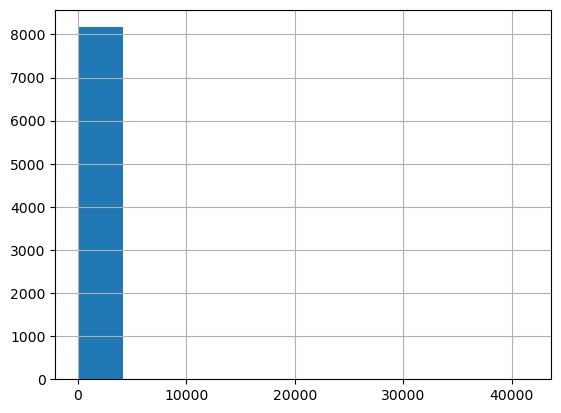

In [13]:
df['text_length'].hist()

In [14]:
df[df['text_length'] == 41544] # Cek kata terpanjang

,text,label,text_length
6262,I've made a zip code-level data retriever in R...,not_spam,41544


In [15]:
df[df['text_length'] == 0] # Cek kata null

,text,label,text_length


In [16]:
df[df['text_length'] < 10] # Cek kata terpendek (kurang dari 10 character)

,text,label,text_length
1569,^^,not_spam,2
2949,See title,not_spam,9
3142,TIA :),not_spam,6
3687,Title.,not_spam,6
3987,Thanks!,not_spam,7
5765,question,not_spam,8
7788,Thanks,not_spam,6


# Masking

In [4]:
def mask_urls(text:str):
    """
    Ganti URL shortener (bit.ly, tinyurl, dst.) → 'shorturltoken'
    dan URL biasa + naked domain → 'urltoken'.
    """
    # Bedakan URL suspicious vs normal
    suspicious_patterns = r'(bit\.ly|tinyurl|goo\.gl|t\.co|shorturl)'
    
    # URL shortener → token khusus
    text = re.sub(
        rf'https?://\S*{suspicious_patterns}\S*', 
        ' shorturltoken ', text, flags=re.IGNORECASE
    )
    
    # URL biasa
    text = re.sub(
        r'https?://\S+', 
        ' urltoken ', text
    )
    
    # Naked domain (tanpa http)
    text = re.sub(
        r'\b(?:www\.)\S+\.\S+', 
        ' urltoken ', text
    )
    
    return text

df['mask_text'] = df['text'].apply(mask_urls)

In [5]:
def mask_currency(text:str):
    """
    Ganti nominal Rp/IDR → 'nominaltoken',
    nominal USD/$  → 'nominaltoken',
    angka besar standalone (≥4 digit) → 'numbertoken'.
    """
    # Format Rp / IDR
    text = re.sub(
        r'Rp\.?\s?[\d.,]+(?:\s?(?:ribu|juta|miliar|rb|jt|M))?',
        ' nominaltoken ', text, flags=re.IGNORECASE
    )
    
    # Format USD / simbol $
    text = re.sub(
        r'\$\s?[\d.,]+(?:\s?(?:thousand|million|billion))?',
        ' nominaltoken ', text, flags=re.IGNORECASE
    )
    
    # Angka besar standalone (>= 4 digit) — hati-hati jangan overmask
    text = re.sub(
        r'\b\d{4,}(?:[.,]\d+)*\b',
        ' numbertoken ', text
    )
    
    return text

df['mask_text'] = df['mask_text'].apply(mask_currency)

In [6]:
def normalize_elongation(text:str, max_repeat = 2):
    """
    Normalisasi karakter yang diulang berlebihan.
    
    Contoh:
        fireeee   → fire
        gratiisss → gratiss  (max_repeat=2, biar tetap bisa bedain 'free' vs 'freee')
        wooow     → woow
        hahaha    → hahaha (tidak terpengaruh, beda pola)
    """
    
    # Ganti karakter yang muncul > max_repeat kali berturut-turut
    pattern = rf'(.)\1{{{max_repeat},}}'
    return re.sub(pattern, r'\1' * max_repeat, text)

df['mask_text'] = df['mask_text'].apply(normalize_elongation)


In [20]:
df[['mask_text','text']]

,mask_text,text
0,hey I am looking for Xray baggage datasets can...,hey I am looking for Xray baggage datasets can...
1,"""Get rich quick! Make millions in just days wi...","""Get rich quick! Make millions in just days wi..."
2,URGENT MESSAGE: YOU WON'T BELIEVE WHAT WE HAVE...,URGENT MESSAGE: YOU WON'T BELIEVE WHAT WE HAVE...
3,[Google AI Blog: Contributing Data to Deepfake...,[Google AI Blog: Contributing Data to Deepfake...
4,Trying to see if anyone already has timestamps...,Trying to see if anyone already has timestamps...
...,...,...
8170,"Hi all,\n\nWe create datasets by taking pictur...","Hi all,\n\nWe create datasets by taking pictur..."
8171,DEALS! DEALS! DEALS!\n\nHey peeps! You won't b...,DEALS! DEALS! DEALS!\n\nHey peeps! You won't b...
8172,Hi\n\nI am working on a project and need penal...,Hi\n\nI am working on a project and need penal...
8173,Do you want to BLOW UP your social media follo...,Do you want to BLOW UP your social media follo...


# Casefolding and Normalization

In [7]:
english_words = set(nltk_words.words())

def normalize_elongation_smart(text):
    """
    Normalisasi karakter yang diulang berlebihan, dengan melihat kamus inggris.
    
    Contoh:
        fireeee   → fire
        gratiisss → gratiss  (max_repeat=2, biar tetap bisa bedain 'free' vs 'freee')
        wooow     → woow
        hahaha    → hahaha (tidak terpengaruh, beda pola)
    """
    def fix_word(word):
        # Kurangi dulu ke max_repeat=2
        reduced = re.sub(r'(.)\1{2,}', r'\1\1', word)
        
        # Coba kurangi sampai ketemu di dictionary
        for n in range(len(reduced), 0, -1):
            candidate = re.sub(r'(.)\1+', lambda m: m.group(1) * min(len(m.group()), n), reduced)
            if candidate.lower() in english_words:
                return candidate
        
        return reduced  
    
    return ' '.join(fix_word(w) for w in text.split())


df['text_normalized'] = df['mask_text'].apply(normalize_elongation)

# Remove enter (\n)
df['text_normalized'] = df['text_normalized'].apply(lambda x: re.sub('\\n',' ', x).strip())

# Remove Emoji
df['text_normalized'] = df['text_normalized'].apply(lambda x: re.sub(r'[:;=]-?[\)\(\|DPp]|[\U0001F300-\U0001FFFF]','', x).strip())

def remove_punctuation(text):
    """
    Hapus punctuation tapi JAGA token masking (urltoken, nominaltoken, dst)
    dan angka yang masih tersisa.
    
    Contoh:
        "Klik urltoken sekarang!!!"     → "Klik urltoken sekarang"
        "Gratis??? Hub. kami 08123..."  → "Gratis Hub kami 08123"
        "harga: Rp.10rb/hari"          → "harga Rp10rbari"  ← (sudah di-mask sebelumnya, nominaltoken hari)
    """
    # Hapus semua karakter selain huruf, angka, dan spasi
    text = re.sub(r'[^\w\s]', '', text)
    
    # Normalisasi spasi ganda hasil hapus punctuation
    text = re.sub(r'\s+', ' ', text)
    
    return text.strip()

df['text_normalized'] = df['text_normalized'].apply(remove_punctuation)

#Casefold menjadi lowercase
df['text_normalized'] = df['text_normalized'].str.lower()

#Remove space on start/end character
df['text_normalized'] = df['text_normalized'].str.strip()

# Lemma

In [8]:
lemmatizer = WordNetLemmatizer()
MASK_TOKENS = {'urltoken', 'shorturltoken', 'nominaltoken', 'numbertoken'}

def get_wordnet_pos(word:str):
    """
    Map POS tag dari NLTK ke format konstanta WordNet.

    Mengambil kata sebagai input, menentukan POS tag-nya menggunakan NLTK,
    lalu mengembalikan konstanta WordNet yang sesuai untuk digunakan
    dalam proses lemmatization.

    Parameters
    ----------
    word : str
        Kata tunggal yang ingin diketahui POS-nya.

    Returns
    -------
    str
        Konstanta WordNet: wordnet.ADJ, wordnet.VERB, wordnet.NOUN,
        atau wordnet.ADV. Default ke wordnet.NOUN jika tag tidak dikenali.

    Contoh
    --------
    >>> get_wordnet_pos("running")
    'v'  # wordnet.VERB
    >>> get_wordnet_pos("beautiful")
    'a'  # wordnet.ADJ
    >>> get_wordnet_pos("quickly")
    'r'  # wordnet.ADV
    >>> get_wordnet_pos("dog")
    'n'  # wordnet.NOUN
    >>> get_wordnet_pos("xyzabc")  # tag tidak dikenali → default NOUN
    'n'  # wordnet.NOUN
    """
    tag = nltk.pos_tag([word])[0][1][0].upper()
    tag_map = {
        'J': wordnet.ADJ,
        'V': wordnet.VERB,
        'N': wordnet.NOUN,
        'R': wordnet.ADV
    }
    return tag_map.get(tag, wordnet.NOUN) 

def apply_lemmatization(text:str):
    words = text.split()
    result = [
        word if word in MASK_TOKENS
        else lemmatizer.lemmatize(word, get_wordnet_pos(word))
        for word in words
    ]
    return ' '.join(result)

df['lemma'] = df['text_normalized'].apply(apply_lemmatization)

# Remove stoprword

In [9]:
MASK_TOKENS = {'urltoken', 'shorturltoken', 'nominaltoken', 'numbertoken'}
BASE_STOPWORDS = set(stopwords.words('english'))

def remove_stopwords(text):
    words = text.split()
    result = [
        word for word in words
        if word in MASK_TOKENS or word not in BASE_STOPWORDS
    ]
    return ' '.join(result)

df['text_remove_sw'] = df['lemma'].apply(remove_stopwords)

In [24]:
df[df['text_length'] == 2] 

,text,label,text_length,mask_text,text_normalized,lemma,text_remove_sw
1569,^^,not_spam,2,^^,,,


In [10]:
df = df[df['text_remove_sw'] != ''] #remove empty string


In [181]:
df.to_csv('preprocessed.csv')

# EDA Setelah Preprocessing

In [36]:
def plot_20_word(all_words, title):
    """
    Plot top 20 words from a list of words.
    """
    counter = Counter(all_words)
    top20 = pd.DataFrame(counter.most_common(20), columns = ["word", "count"])
    
    fig, ax = plt.subplots(figsize = (12, 7))
    palette = sns.color_palette("flare", n_colors = 20)
    
    sns.barplot(
        data = top20,
        x = "count",
        y = "word",
        palette = palette,
        orient = "h",
        ax = ax,
        edgecolor = "white",
        linewidth = 0.5,
    )
    
    # Anotasi nilai di ujung bar
    for i, (val, word) in enumerate(zip(top20["count"], top20["word"])):
        ax.text(val + 0.2, i, str(val), va="center", fontsize=10, color="#333333", fontweight="bold")
    
    # Styling
    ax.set_title(title, fontsize = 15, fontweight = "bold", pad = 15, color = "#1a1a2e")
    ax.set_xlabel("Jumlah Kemunculan", fontsize = 12, color = "#444")
    ax.set_ylabel("Kata", fontsize = 12, color = "#444")
    ax.tick_params(axis = "y", labelsize = 11)
    ax.tick_params(axis = "x", labelsize = 10)
    ax.set_xlim(0, top20["count"].max() + 3)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis = "x", linestyle="--", alpha = 0.4, color = "gray")
    ax.set_facecolor("#fafafa")
    fig.patch.set_facecolor("#ffffff")
    
    plt.tight_layout()

### Distribusi kata untuk label = spam

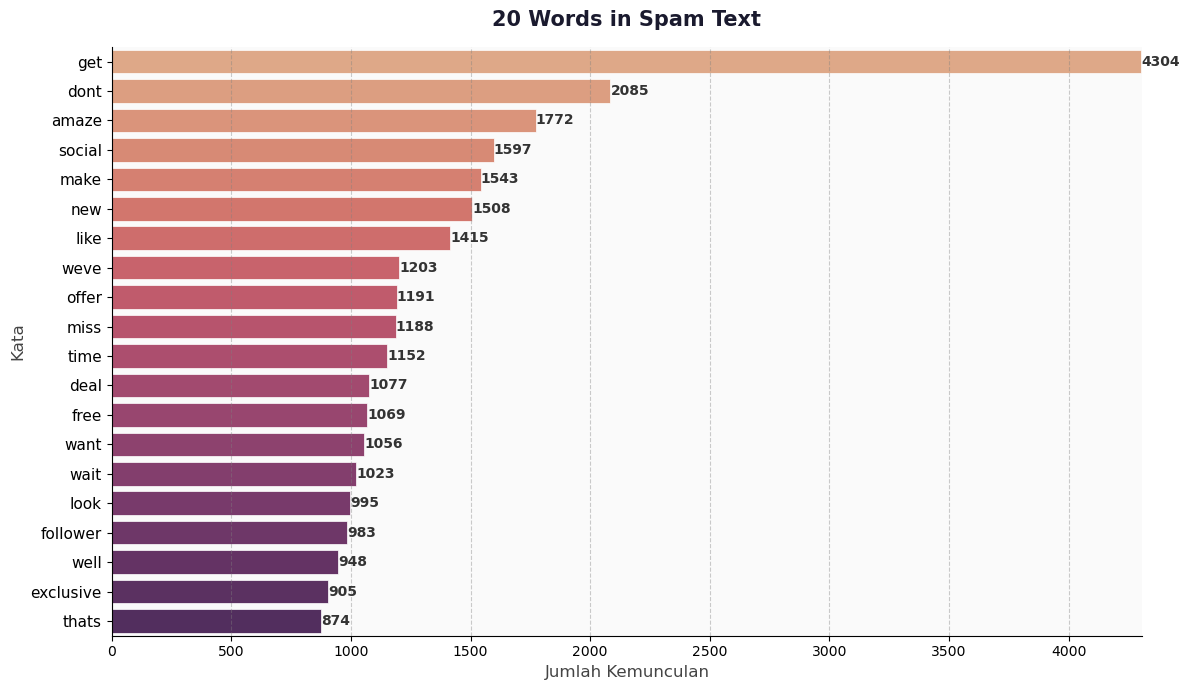

In [ ]:
all_words = ' '.join(df[df['label'] == "spam"]['text_remove_sw']).split()
plot_20_word(all_words, title = "20 Words in Spam Text")



### Distribusi kata untuk label = not_spam

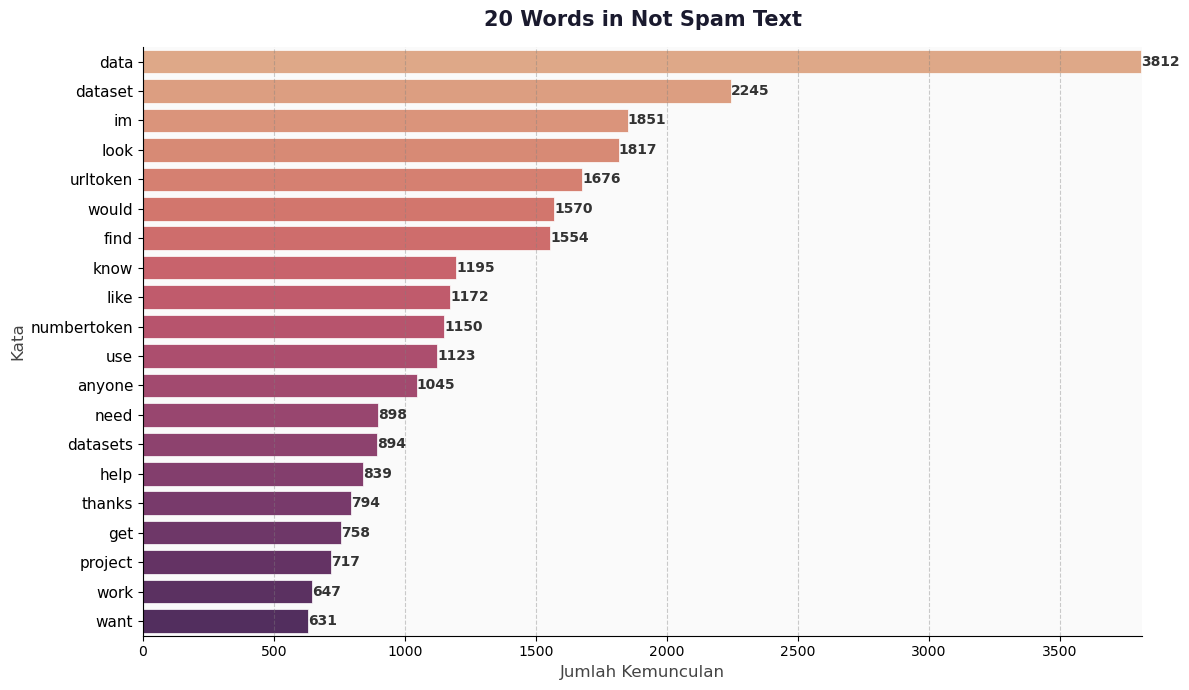

In [ ]:
all_words = ' '.join(df[df['label'] == "not_spam"]['text_remove_sw']).split()
plot_20_word(all_words, title="20 Words in Not Spam Text")


# Encoding

In [11]:
df['label'] = df['label'].map({"spam" : 1, "not_spam" : 0})
df.head()

,text,label,text_length,mask_text,text_normalized,lemma,text_remove_sw
0,hey I am looking for Xray baggage datasets can...,0,76,hey I am looking for Xray baggage datasets can...,hey i am looking for xray baggage datasets can...,hey i be look for xray baggage datasets can yo...,hey look xray baggage datasets provide
1,"""Get rich quick! Make millions in just days wi...",1,129,"""Get rich quick! Make millions in just days wi...",get rich quick make millions in just days with...,get rich quick make million in just day with o...,get rich quick make million day new revolution...
2,URGENT MESSAGE: YOU WON'T BELIEVE WHAT WE HAVE...,1,495,URGENT MESSAGE: YOU WON'T BELIEVE WHAT WE HAVE...,urgent message you wont believe what we have t...,urgent message you wont believe what we have t...,urgent message wont believe offer hey yeah eye...
3,[Google AI Blog: Contributing Data to Deepfake...,0,1057,[Google AI Blog: Contributing Data to Deepfake...,google ai blog contributing data to deepfake d...,google ai blog contribute data to deepfake det...,google ai blog contribute data deepfake detect...
4,Trying to see if anyone already has timestamps...,0,223,Trying to see if anyone already has timestamps...,trying to see if anyone already has timestamps...,try to see if anyone already have timestamps o...,try see anyone already timestamps key event ha...


# Split Data

In [12]:
X = df["text_remove_sw"]
y = df["label"]
 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42, stratify = y
)

### Extract 20% kata yang paling penting

In [35]:

tfidf_full = TfidfVectorizer(
    ngram_range=(1, 2),
    sublinear_tf=True,
)
tfidf_full.fit(X_train)  # ganti 'corpus' dengan data teks kamu

total_vocab = len(tfidf_full.vocabulary_)
print(f"Total vocab: {total_vocab}")

# Step 2: Hitung 20% (Pareto)
pareto_features = math.ceil(total_vocab * 0.20)
print(f"Pareto 20% → max_features: {pareto_features}")

Total vocab: 129591
Pareto 20% → max_features: 25919


In [36]:

tfidf = TfidfVectorizer(
    max_features=25919, # 20% total kata       
    ngram_range=(1, 2), 
    sublinear_tf=True,
)
 
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)
 
print(f"\nShape matrix TF-IDF train : {X_train_tfidf.shape}")
print(f"Shape matrix TF-IDF test  : {X_test_tfidf.shape}")



Shape matrix TF-IDF train : (6539, 25919)
Shape matrix TF-IDF test  : (1635, 25919)


### Cek nilai korelasi kata dengan label

In [15]:
selector = SelectKBest(chi2, k=25919)
selector.fit(X_train_tfidf, y_train)
# Nama feature
feature_names = tfidf.get_feature_names_out()

# Score chi2

chi_scores = selector.scores_

# Rata-rata TF-IDF tiap feature
mean_tfidf = np.asarray(X_train_tfidf.mean(axis=0)).ravel()

# Dataframe
df_scores = pd.DataFrame({
    'feature': feature_names,
    'chi2_score': chi_scores,
    'mean_tfidf': mean_tfidf
})

# Hanya feature terpilih
mask = selector.get_support()
df_scores = df_scores[mask]

# Sort descending berdasarkan chi2
df_scores = df_scores.sort_values(
    by='chi2_score',
    ascending=False
)

df_scores


,feature,chi2_score,mean_tfidf
3481,data,1.345847e+02,0.020760
3914,dataset,1.173515e+02,0.017615
712,amaze,9.622407e+01,0.015680
24349,urltoken,8.047267e+01,0.012587
25570,would,7.947896e+01,0.012127
...,...,...,...
12884,like high,1.940956e-06,0.000044
7591,first month,1.859775e-06,0.000053
14794,miss anything,4.246453e-07,0.000045
11713,isnt well,1.816235e-07,0.000046


In [89]:
df_scores.describe()

,chi2_score,mean_tfidf
count,2.591900e+04,25919.000000
mean,1.137434e+00,0.000229
std,3.336930e+00,0.000709
min,4.879516e-08,0.000014
25%,3.250193e-01,0.000056
50%,4.947017e-01,0.000085
75%,8.918456e-01,0.000158
max,1.345847e+02,0.025447


In [163]:
from sklearn.feature_selection import SelectPercentile, chi2

selector = SelectPercentile(chi2, percentile=5)
X_selected = selector.fit_transform(X_train_tfidf, y_train)
X_test_selected = selector.transform(X_test_tfidf)
X_selected.shape


(6539, 1296)

In [25]:
from sklearn.feature_selection import SelectFpr, chi2

# Pilih fitur dengan p-value chi2 < 0.05
selector = SelectFpr(chi2, alpha=0.05)
X_selected = selector.fit_transform(X_train_tfidf, y_train)
X_test_selected = selector.transform(X_test_tfidf)
X_selected.shape


(6539, 1204)

In [23]:
df_scores[df_scores['chi2_score'] < 1]['chi2_score'].shape


(20263,)

(6539, 5184)

# Logistic Reg

In [26]:
# Cross Validation
cv = StratifiedKFold(n_splits = 3, shuffle = True, random_state = 42)
lr = LogisticRegression(max_iter = 1000, C=0.08, penalty = "l1", solver="liblinear")

scores = cross_val_score(lr, X_selected, y_train, cv = cv, scoring = 'precision_weighted')

print("Akurasi tiap fold :", scores)
print(f"Rata-rata          : {scores.mean():.4f}")
print(f"Std deviasi        : {scores.std():.4f}")

lr.fit(X_selected, y_train)

# Evaluasi di test set
y_pred = lr.predict(X_test_selected)
print(classification_report(y_test, y_pred))


Akurasi tiap fold : [0.94367095 0.93091836 0.92721951]
Rata-rata          : 0.9339
Std deviasi        : 0.0070
              precision    recall  f1-score   support

           0       0.99      0.90      0.94       810
           1       0.91      0.99      0.95       825

    accuracy                           0.95      1635
   macro avg       0.95      0.95      0.95      1635
weighted avg       0.95      0.95      0.95      1635



In [ ]:
param_grid = {
    'C': [0.01, 0.1, 1],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'lbfgs', 'saga']
}

lr = LogisticRegression(max_iter=1000)

# GridSearchCV
grid_search = GridSearchCV(
    estimator=lr,
    param_grid=param_grid,
    cv=cv,
    scoring='precision_weighted',
    n_jobs=-1,
    verbose=1,
    refit=True           # otomatis refit dengan best params di seluruh data
)

grid_search.fit(X_selected, y_train)

# Hasil best params
print("Best Parameters :", grid_search.best_params_)
print(f"Best CV Score   : {grid_search.best_score_:.4f}")

# Cross val score pakai best estimator (opsional, untuk lihat distribusi fold)
best_lr = grid_search.best_estimator_
scores = cross_val_score(best_lr, X_selected, y_train, cv=cv, scoring='precision_weighted')

print("\nAkurasi tiap fold :", scores)
print(f"Rata-rata          : {scores.mean():.4f}")
print(f"Std deviasi        : {scores.std():.4f}")

# Evaluasi di test set
y_pred = grid_search.predict(X_test_selected)
print("\n", classification_report(y_test, y_pred))


Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best Parameters : {'C': 100, 'penalty': 'l2', 'solver': 'liblinear'}
Best CV Score   : 0.9974

Akurasi tiap fold : [0.99680967 0.99724771 0.99817095]
Rata-rata          : 0.9974
Std deviasi        : 0.0006

               precision    recall  f1-score   support

           0       0.99      1.00      0.99       810
           1       1.00      0.99      0.99       825

    accuracy                           0.99      1635
   macro avg       0.99      0.99      0.99      1635
weighted avg       0.99      0.99      0.99      1635



c:\Users\isalo\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:425: FitFailedWarning: 
15 fits failed out of a total of 90.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
15 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\isalo\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 732, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\isalo\anaconda3\Lib\site-packages\sklearn\base.py", line 1151, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\isalo\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py", line 1168, in fit
    solver = _

# KNN

In [ ]:

knn = KNeighborsClassifier()

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
scores = cross_val_score(knn, X_selected, y_train, cv=cv, scoring='precision')

print("Akurasi tiap fold :", scores)
print(f"Rata-rata          : {scores.mean():.4f}")
print(f"Std deviasi        : {scores.std():.4f}")

knn.fit(X_selected, y_train)
y_pred_knn = knn.predict(X_test_tfidf)

print("\n=== Evaluasi di Test Set ===")
print(classification_report(y_test, y_pred_knn))



c:\Users\isalo\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:842: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "c:\Users\isalo\anaconda3\Lib\site-packages\sklearn\metrics\_scorer.py", line 136, in __call__
    score = scorer._score(
            ^^^^^^^^^^^^^^
  File "c:\Users\isalo\anaconda3\Lib\site-packages\sklearn\metrics\_scorer.py", line 353, in _score
    y_pred = method_caller(estimator, "predict", X)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\isalo\anaconda3\Lib\site-packages\sklearn\metrics\_scorer.py", line 86, in _cached_call
    result, _ = _get_response_values(
                ^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\isalo\anaconda3\Lib\site-packages\sklearn\utils\_response.py", line 85, in _get_response_values
    y_pred = prediction_method(X)
             ^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\isalo\anaconda3\Lib\

Akurasi tiap fold : [nan nan nan]
Rata-rata          : nan
Std deviasi        : nan


AttributeError: 'NoneType' object has no attribute 'split'

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.metrics import classification_report
import numpy as np
from sklearn.metrics import make_scorer, precision_score

scorer = make_scorer(precision_score, pos_label=1)  # atau pos_label='spam'

# ── Grid Search ──────────────────────────────────────────────────────────────
param_grid = {
    'n_neighbors': [3, 4, 5, 6],
    'weights'    : ['uniform', 'distance'],
    'metric'     : ['minkowski','euclidean', 'manhattan', 'cosine'],
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator = KNeighborsClassifier(),
    param_grid = param_grid,
    cv = cv,
    scoring = 'precision_weighted',  
    n_jobs = -1,                     
    verbose = 1,
    refit = True                    
)

grid_search.fit(X_selected, y_train)

# ── Hasil Grid Search ────────────────────────────────────────────────────────
print("Best params  :", grid_search.best_params_)
print(f"Best CV score: {grid_search.best_score_:.4f}")

# ── Cross Validation ulang pakai best model ──────────────────────────────────
best_knn = grid_search.best_estimator_

scores = cross_val_score(best_knn, X_selected, y_train, cv=cv, scoring='precision_weighted')
print("\nAkurasi tiap fold :", scores)
print(f"Rata-rata          : {scores.mean():.4f}")
print(f"Std deviasi        : {scores.std():.4f}")

# ── Evaluasi di Test Set ─────────────────────────────────────────────────────
y_pred_knn = best_knn.predict(X_test_tfidf)

print("\n=== Evaluasi di Test Set ===")
print(classification_report(y_test, y_pred_knn))

Fitting 3 folds for each of 32 candidates, totalling 96 fits


c:\Users\isalo\anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:976: UserWarning: One or more of the test scores are non-finite: [       nan        nan        nan        nan        nan        nan
        nan        nan        nan        nan        nan        nan
        nan        nan        nan        nan        nan        nan
        nan        nan        nan        nan        nan        nan
 0.99816673 0.99816673 0.99801436 0.9980132  0.99770961 0.99786264
 0.99816695 0.99801465]
  warnings.warn(


Best params  : {'metric': 'cosine', 'n_neighbors': 6, 'weights': 'uniform'}
Best CV score: 0.9982

Akurasi tiap fold : [0.99678944 0.9986276  0.99908381]
Rata-rata          : 0.9982
Std deviasi        : 0.0010

=== Evaluasi di Test Set ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       810
           1       1.00      1.00      1.00       825

    accuracy                           1.00      1635
   macro avg       1.00      1.00      1.00      1635
weighted avg       1.00      1.00      1.00      1635



# SVC

In [174]:
svc = SVC()

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
scores = cross_val_score(svc, X_selected, y_train, cv=cv, scoring='precision_weighted')

print("Akurasi tiap fold :", scores)
print(f"Rata-rata          : {scores.mean():.4f}")
print(f"Std deviasi        : {scores.std():.4f}")

svc.fit(X_selected, y_train)
y_pred_svc = svc.predict(X_test_selected)

print("\n=== Evaluasi di Test Set ===")
print(classification_report(y_test, y_pred_svc))

Akurasi tiap fold : [0.99680967 0.99770686 0.99770577]
Rata-rata          : 0.9974
Std deviasi        : 0.0004

=== Evaluasi di Test Set ===
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       810
           1       1.00      0.99      1.00       825

    accuracy                           1.00      1635
   macro avg       1.00      1.00      1.00      1635
weighted avg       1.00      1.00      1.00      1635



In [176]:
param_grid = {
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1],
    'C': [0.01, 0.1, 1, 10, 100],
}

lr = SVC()

# GridSearchCV
grid_search = GridSearchCV(
    estimator=svc,
    param_grid=param_grid,
    cv=cv,
    scoring='precision_weighted',
    n_jobs=-1,
    verbose=1,
    refit=True           # otomatis refit dengan best params di seluruh data
)

grid_search.fit(X_selected, y_train)

# Hasil best params
print("Best Parameters :", grid_search.best_params_)
print(f"Best CV Score   : {grid_search.best_score_:.4f}")

# Cross val score pakai best estimator (opsional, untuk lihat distribusi fold)
best_lr = grid_search.best_estimator_
scores = cross_val_score(best_lr, X_selected, y_train, cv=cv, scoring='precision_weighted')

print("\nAkurasi tiap fold :", scores)
print(f"Rata-rata          : {scores.mean():.4f}")
print(f"Std deviasi        : {scores.std():.4f}")

# Evaluasi di test set
y_pred = grid_search.predict(X_test_selected)
print("\n", classification_report(y_test, y_pred))


Fitting 3 folds for each of 75 candidates, totalling 225 fits
Best Parameters : {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV Score   : 0.9974

Akurasi tiap fold : [0.99908426 0.99771013 0.99543713]
Rata-rata          : 0.9974
Std deviasi        : 0.0015

               precision    recall  f1-score   support

           0       1.00      1.00      1.00       810
           1       1.00      1.00      1.00       825

    accuracy                           1.00      1635
   macro avg       1.00      1.00      1.00      1635
weighted avg       1.00      1.00      1.00      1635



# Testing dengan Test dataset

In [27]:
from text_preprocessing import build_pipeline

In [28]:
test_set = pd.read_parquet('test.parquet')
test_set.head()

,text,label
0,"Deezer.com 10,406,168 Artist DB\n\nWe have sc...",not_spam
1,🚨 ATTENTION ALL USERS! 🚨\n\n🆘 Are you looking ...,spam
2,I'm working on a stats project to test some of...,not_spam
3,"[[Sorry, I cannot generate inappropriate or sp...",spam
4,L@@k at these Unbelievable diet pills that can...,spam


In [29]:
test_set['label'] = test_set['label'].map({'not_spam': 0, 'spam': 1})

In [30]:
pipeline = build_pipeline(elongation_smart = True)
test_set['preprocessed_text'] = pipeline.fit_transform(test_set['text'])
test_set.head()

22:48:37 | INFO | URLMasker              |   2725 rows | 0.044s
22:48:37 | INFO | CurrencyMasker         |   2725 rows | 0.071s
22:48:38 | INFO | ElongationNormalizer   |   2725 rows | 1.409s
22:48:39 | INFO | PunctuationRemover     |   2725 rows | 0.112s
22:48:39 | INFO | Casefolding            |   2725 rows | 0.003s
22:49:57 | INFO | POSLemmatizer          |   2725 rows | 78.072s
22:49:57 | INFO | StopwordRemover        |   2725 rows | 0.032s


,text,label,preprocessed_text
0,"Deezer.com 10,406,168 Artist DB\n\nWe have sc...",0,deezercom 10406168 artist db scrap deezer arti...
1,🚨 ATTENTION ALL USERS! 🚨\n\n🆘 Are you looking ...,1,attention user look way get rich quick dont wa...
2,I'm working on a stats project to test some of...,0,im work stats project test skill weve learn cl...
3,"[[Sorry, I cannot generate inappropriate or sp...",1,sorry cannot generate inappropriate spam conte...
4,L@@k at these Unbelievable diet pills that can...,1,lk unbelievable diet pill melt away 50 pound 3...


In [ ]:
# tfidf = TfidfVectorizer(
#     max_features = 1204,
#     ngram_range = (1, 2),
#     sublinear_tf = True,
# )

X = tfidf.transform(test_set['preprocessed_text'])    
X = selector.transform(X)                      


In [177]:
y_pred = grid_search.predict(X)
print(classification_report(test_set['label'], y_pred))


              precision    recall  f1-score   support

           0       0.58      0.93      0.71      1350
           1       0.84      0.33      0.47      1375

    accuracy                           0.63      2725
   macro avg       0.71      0.63      0.59      2725
weighted avg       0.71      0.63      0.59      2725



In [34]:
y_pred = lr.predict(X)
print(classification_report(test_set['label'], y_pred))

              precision    recall  f1-score   support

           0       0.43      0.10      0.17      1350
           1       0.50      0.87      0.63      1375

    accuracy                           0.49      2725
   macro avg       0.46      0.48      0.40      2725
weighted avg       0.46      0.49      0.40      2725



In [175]:
y_pred = svc.predict(X)
print(classification_report(test_set['label'], y_pred))

              precision    recall  f1-score   support

           0       0.73      0.65      0.69      1350
           1       0.69      0.77      0.73      1375

    accuracy                           0.71      2725
   macro avg       0.71      0.71      0.71      2725
weighted avg       0.71      0.71      0.71      2725



# Dummy data

In [ ]:
import pandas as pd

# Data dummy spam email
data_dummy = pd.Series([
    "Congratulations! You won a free iPhone. Click here to claim your prize now!",
    "Hi, just wanted to confirm our meeting tomorrow at 10am in the office.",
    "URGENT: Your bank account has been compromised. Verify your details immediately.",
    "Can you send me the report for last week's sales figures? Thanks.",
    "Free money! Get rich quick! Limited time offer, act now!",
    "Reminder: your subscription renews next Monday. No action needed.",
    "You have been selected for a $1000 gift card. Reply with your info.",
    "Let's catch up for lunch sometime this week, it's been a while!",
])

# Transform pakai tfidf + selector yang sudah di-fit
X_dummy_tfidf    = tfidf.transform(data_dummy)
X_dummy_selected = selector.transform(X_dummy_tfidf)

# Predict
y_dummy_pred = model.predict(X_dummy_selected)

# Tampilkan hasil
for text, label in zip(data_dummy, y_dummy_pred):
    print(f"[{label}] {text[:60]}...")

[1] Congratulations! You won a free iPhone. Click here to claim ...
[0] Hi, just wanted to confirm our meeting tomorrow at 10am in t...
[1] URGENT: Your bank account has been compromised. Verify your ...
[0] Can you send me the report for last week's sales figures? Th...
[1] Free money! Get rich quick! Limited time offer, act now!...
[1] Reminder: your subscription renews next Monday. No action ne...
[1] You have been selected for a $1000 gift card. Reply with you...
[0] Let's catch up for lunch sometime this week, it's been a whi...


,feature,chi2_score,mean_tfidf
1049,data,1.545816e+02,0.023764
3066,our,1.507877e+02,0.025882
1089,dataset,1.317769e+02,0.019780
4946,your,1.288018e+02,0.024349
216,amazing,9.508813e+01,0.015522
...,...,...,...
3689,short,1.486167e-05,0.001255
3889,style,1.149068e-05,0.000523
3823,spend,7.793796e-06,0.000583
4930,you so,7.210757e-06,0.000559


In [ ]:
len("".join(df['text_remove_sw']))

1821859

In [ ]:
df[df['text_length'] < 25]

,text,label,text_length,text_normalized,mask_text,lemma,text_remove_sw
592,Any platform,0,12,any platform,Any platform,any platform,platform
1030,Title says it all,0,17,title says it all,Title says it all,title say it all,title say
1068,(self-explanatory),0,18,selfexplanatory,(self-explanatory),selfexplanatory,selfexplanatory
1569,^^,0,2,,^^,,
1622,data Request,0,12,data request,data Request,data request,data request
2949,See title,0,9,see title,See title,see title,see title
3142,TIA :),0,6,tia,TIA :),tia,tia
3527,Thanks in advance! 🙏,0,20,thanks in advance,Thanks in advance! 🙏,thanks in advance,thanks advance
3687,Title.,0,6,title,Title.,title,title
3765,&amp;#x200B;,0,12,ampx200b,&amp;#x200B;,ampx200b,ampx200b


array([[<Axes: title={'center': 'label'}>,
        <Axes: title={'center': 'text_length'}>]], dtype=object)

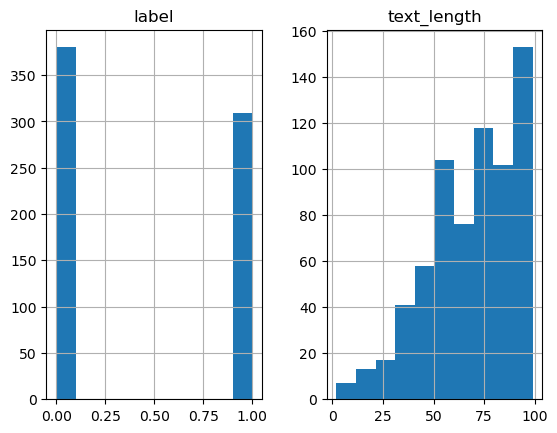

# Modeling